# 🏟️ LaLiga Team Playing Style — Feature Engineering & Style Scoring

---

## 📋 Project Overview

**Tujuan Notebook:**  
Notebook ini merupakan tahap persiapan data untuk analisis clustering gaya bermain tim LaLiga.  
Tujuan utamanya adalah:

1. **Feature Selection** — Memilih fitur-fitur yang merepresentasikan gaya bermain tim secara konseptual (bukan random).
2. **Feature Engineering** — Menormalisasi fitur terpilih menggunakan Min-Max Scaling (skala 0–100).
3. **Style Scoring** — Menghitung skor komposit untuk 9 dimensi gaya bermain.

**Input:**
- Tabel `gold.teams_statistics` dari PostgreSQL — One Big Table (OBT) berisi 124+ kolom statistik 20 tim LaLiga musim 2024/25.

**Output:**
- DataFrame `teams_ml_features` berisi **club + 9 style scores** (skala 0–100) yang siap digunakan pada notebook clustering berikutnya.

**Catatan Penting:**
> ⚠️ Notebook ini **TIDAK** melakukan clustering. Notebook ini hanya menghasilkan dataset fitur yang siap digunakan oleh notebook clustering berikutnya.

---

### 9 Dimensi Gaya Bermain

| # | Style Score | Tujuan |
|---|------------|--------|
| 1 | **Possession Score** | Mengukur dominasi penguasaan bola |
| 2 | **Direct Play Score** | Mengukur kecenderungan bermain langsung |
| 3 | **Pressing Score** | Mengukur intensitas pressing |
| 4 | **Attacking Efficiency Score** | Mengukur efektivitas penyelesaian serangan |
| 5 | **Defensive Solidity Score** | Mengukur kekuatan bertahan |
| 6 | **Set Piece Score** | Mengukur ancaman dari bola mati |
| 7 | **Chance Creation Score** | Mengukur kemampuan menciptakan peluang |
| 8 | **Transition Score** | Mengukur kecepatan & efektivitas transisi |
| 9 | **Discipline Score** | Mengukur kedisiplinan (inverted — semakin sedikit pelanggaran, semakin tinggi skor) |

---

## 1. Import Library

Library yang digunakan:
- **pandas** & **numpy** — manipulasi data dan komputasi numerik
- **matplotlib** — visualisasi statis (radar chart)
- **plotly** — visualisasi interaktif
- **sqlalchemy** — koneksi ke PostgreSQL
- **sklearn.preprocessing** — MinMaxScaler untuk normalisasi
- **dotenv** — membaca credential database dari file `.env`

In [1]:
# === Standard Library ===
import os
import warnings
from pathlib import Path

# === Data Manipulation ===
import numpy as np
import pandas as pd

# === Visualization ===
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# === Database ===
from sqlalchemy import create_engine
from dotenv import load_dotenv

# === Preprocessing ===
from sklearn.preprocessing import MinMaxScaler

# === Settings ===
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Semua library berhasil diimpor.")

✅ Semua library berhasil diimpor.


---

## 2. Load Data dari PostgreSQL

Data dimuat langsung dari tabel **`gold.teams_statistics`** di PostgreSQL.  
Tabel ini merupakan *One Big Table (OBT)* yang sudah menggabungkan 12 sub-tabel statistik tim LaLiga menjadi satu tabel dengan 124+ kolom.

Koneksi database menggunakan **SQLAlchemy** dengan credential yang dibaca dari file `.env`.

In [2]:
# --- Konfigurasi Database ---
# Membaca credential dari .env di root project
PROJECT_ROOT = Path.cwd().parent
load_dotenv(PROJECT_ROOT / ".env")

DB_URL = (
    f"postgresql://{os.getenv('DB_USER', 'g')}:{os.getenv('DB_PASSWORD', '')}"
    f"@{os.getenv('DB_HOST', 'localhost')}:{os.getenv('DB_PORT', '5432')}"
    f"/{os.getenv('DB_NAME', 'laliga')}"
)

engine = create_engine(DB_URL)
print(f"✅ Engine created: {engine.url.database}@{engine.url.host}")

✅ Engine created: laliga@localhost


In [3]:
# --- Load Gold OBT ---
query = "SELECT * FROM gold.teams_statistics ORDER BY club"
df_raw = pd.read_sql(query, engine)

print(f"Shape: {df_raw.shape}  ({df_raw.shape[0]} tim, {df_raw.shape[1]} kolom)")
print(f"Clubs: {df_raw['club'].nunique()} tim unik")

Shape: (20, 124)  (20 tim, 124 kolom)
Clubs: 20 tim unik


In [4]:
# --- Preview Data (5 baris pertama) ---
df_raw.head()

,club,played,att_goals,att_xg,att_goals_vs_xg,att_shots,att_sot,att_conversion_pct,att_xg_per_shot,att_np_goals,att_np_xg,att_np_goals_vs_xg,att_np_shots,att_np_sot,att_np_conv_pct,att_np_xg_per_shot,att_sp_goals,att_sp_shots,att_sp_xg,att_sp_goal_pct,att_sp_shot_pct,att_sp_xg_pct,att_touches_in_box,att_hit_woodwork,att_offsides,att_penalties_total,att_penalties_goals,att_free_kicks_total,att_free_kicks_goals,att_headers_total,att_headers_goals,att_fast_breaks_total,att_fast_breaks_goals,def_avg_possession_pct,def_tackles,def_interceptions,def_possession_won,def_blocks,def_clearances,def_ground_duels_won_pct,def_aerial_duels_won_pct,def_goals_conceded,def_xg_against,def_goals_vs_xg_against,def_shots_against,def_sot_against,def_conv_pct_against,def_xg_per_shot_against,def_shots_in_box_pct,def_goals_in_box_pct,def_sp_goals,def_sp_shots,def_sp_xg,def_sp_goal_pct,def_sp_shot_pct,def_sp_xg_pct,def_touches_in_box,def_hit_woodwork,def_offsides,def_penalties_total,def_penalties_goals,def_free_kicks_total,def_free_kicks_goals,def_headers_total,def_headers_goals,def_fast_breaks_total,def_fast_breaks_goals,pas_passes_total,pas_passes_successful,pas_passes_pct,pas_final_third_total,pas_final_third_successful,pas_final_third_pct,pas_direction_fwd_pct,pas_direction_bwd_pct,pas_direction_left_pct,pas_direction_right_pct,pas_crosses_total,pas_crosses_successful,pas_crosses_pct,pas_through_balls,prs_pressed_seqs,prs_ppda,prs_start_distance,prs_high_turnovers_total,prs_high_turnovers_shot_ending,prs_high_turnovers_goal_ending,prs_high_turnovers_shot_pct,seq_passes_10_plus,seq_direct_speed,seq_passes_per_seq,seq_sequence_time,seq_buildups_total,seq_buildups_goals,seq_direct_attacks_total,seq_direct_attacks_goals,msc_subs_used,msc_subs_goals,msc_errors_lead_to_shot,msc_errors_lead_to_goal,msc_fouled,msc_yellows,msc_reds,msc_pens_won,msc_fouls,msc_opp_yellows,msc_opp_reds,msc_pens_conceded,att_goals_per_game,att_shots_per_game,att_xg_per_game,att_fast_breaks_per_game,att_touches_in_box_per_game,def_tackles_per_game,def_interceptions_per_game,def_goals_conceded_per_game,pas_passes_per_game,pas_crosses_per_game,pas_through_balls_per_game,prs_pressed_seqs_per_game,seq_buildups_per_game,seq_direct_attacks_per_game,msc_fouls_per_game,msc_yellows_per_game
0,Alaves,38,44,47.05,-3.05,463,153,9.50,0.10,37,41.54,-4.54,456,146,8.11,0.09,11,135,11.00,25.00,29.16,23.37,778,12,74,7,7,10,1,82,6,29,1,48.00,691,297,1859,148,901,47.50,49.40,56,47.67,8.33,473,154,11.84,0.10,64.69,87.50,6,154,12.54,10.71,32.56,26.31,854,10,55,5,5,13,0,94,7,30,8,15362,12346,80.40,4305,2915,67.70,34.80,15.90,24.60,24.80,538,117,21.80,32,416,11.50,41.40,233,44,4,18.88,299,1.81,3.14,8.01,56,2,47,1,172,6,19,4,489,86,5,7,539,75,6,5,1.16,12.18,1.24,0.76,20.47,18.18,7.82,1.47,404.26,14.16,0.84,10.95,1.47,1.24,14.18,2.26
1,Athletic Bilbao,38,43,50.60,-7.60,522,172,8.24,0.10,38,45.87,-7.87,516,166,7.36,0.09,6,139,10.55,13.95,26.63,20.85,978,12,52,6,5,20,0,95,5,18,4,48.60,571,349,1983,78,808,45.50,49.60,58,42.24,15.76,357,161,16.25,0.12,64.43,79.31,9,88,5.53,15.52,24.65,13.08,610,4,127,6,3,7,2,50,5,38,7,15562,12496,80.30,5114,3421,66.90,35.00,14.60,25.50,25.00,698,137,19.60,59,557,11.20,45.00,368,61,3,16.58,276,2.03,3.08,8.12,57,2,42,5,189,8,27,6,391,73,7,6,497,75,4,6,1.13,13.74,1.33,0.47,25.74,15.03,9.18,1.53,409.53,18.37,1.55,14.66,1.50,1.11,13.08,1.92
2,Atlético Madrid,38,62,58.87,3.13,498,193,12.45,0.12,59,55.71,3.29,494,189,11.94,0.11,12,132,11.00,19.35,26.51,18.68,1060,15,79,4,3,10,2,105,12,33,8,53.30,647,297,1839,114,812,48.60,53.80,44,48.98,-4.98,441,142,9.98,0.11,61.45,81.82,9,133,11.22,20.45,30.16,22.90,752,9,59,6,5,15,0,82,7,27,7,19208,16443,85.60,5438,4121,75.80,30.20,15.70,27.10,27.00,561,130,23.20,100,427,12.20,42.30,267,31,5,11.61,495,1.70,4.16,11.03,124,6,64,2,184,18,22,4,345,77,5,4,399,75,2,6,1.63,13.11,1.55,0.87,27.89,17.03,7.82,1.16,505.47,14.76,2.63,11.24,3.26,1.68,10.50,2.03
3,Barcelona,38,95,86.62,8.38,692,257,13.73,0.13,88,78.73,9.27,682,250,12.90,0.12,15,155,11.48,15.79,

In [5]:
# --- Informasi Tipe Data & Memory ---
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Columns: 124 entries, club to msc_yellows_per_game
dtypes: float64(54), int64(69), str(1)
memory usage: 19.7 KB


In [6]:
# --- Statistik Deskriptif ---
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
played,20.00,38.00,0.00,38.00,38.00,38.00,38.00,38.00
att_goals,20.00,51.20,15.97,26.00,43.00,46.50,59.00,95.00
att_xg,20.00,51.49,12.84,30.59,45.34,49.36,54.72,86.62
att_goals_vs_xg,20.00,-0.29,6.77,-12.19,-5.80,0.20,3.77,12.96
att_shots,20.00,474.30,86.12,352.00,422.00,459.00,504.00,692.00
...,...,...,...,...,...,...,...,...
prs_pressed_seqs_per_game,20.00,10.72,1.51,7.71,9.95,10.50,11.25,14.66
seq_buildups_per_game,20.00,2.00,1.34,0.24,1.26,1.48,2.31,6.08
seq_direct_attacks_per_game,20.00,1.47,0.51,0.47,1.21,1.39,1.69,2.71
msc_fouls_per_game,20.00,11.90,1.56,9.16,11.01,11.78,12.84,14.26


---

## 3. Feature Understanding

Tabel `gold.teams_statistics` memiliki **124+ kolom**. Namun, **tidak semua kolom relevan** untuk mengukur gaya bermain tim.

### Prinsip Pemilihan Feature

Feature dipilih **secara konseptual** berdasarkan:
1. **Representasi gaya bermain** — Setiap feature harus mencerminkan aspek spesifik dari cara sebuah tim bermain.
2. **Interpretabilitas** — Feature harus bisa dijelaskan secara logis dalam konteks sepakbola.
3. **Menghindari redundansi** — Jika dua kolom mengukur hal yang sama, cukup pilih salah satu.
4. **Per-game metrics lebih diutamakan** — Untuk metrik absolut (jumlah total), diutamakan versi *per game* agar perbandingan antar-tim lebih fair.

### Kolom yang TIDAK dipakai
- `played` — Semua tim bermain 38 pertandingan (konstan, tidak informatif).
- Kolom redundan — Misalnya `att_goals` dan `att_goals_per_game` mengukur hal yang sama; cukup pilih salah satu.
- Kolom identitas — `club` dipakai sebagai label, bukan fitur.

In [7]:
# --- Daftar Semua Kolom ---
print(f"Total kolom: {len(df_raw.columns)}\n")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:3d}. {col}")

Total kolom: 124

    1. club
    2. played
    3. att_goals
    4. att_xg
    5. att_goals_vs_xg
    6. att_shots
    7. att_sot
    8. att_conversion_pct
    9. att_xg_per_shot
   10. att_np_goals
   11. att_np_xg
   12. att_np_goals_vs_xg
   13. att_np_shots
   14. att_np_sot
   15. att_np_conv_pct
   16. att_np_xg_per_shot
   17. att_sp_goals
   18. att_sp_shots
   19. att_sp_xg
   20. att_sp_goal_pct
   21. att_sp_shot_pct
   22. att_sp_xg_pct
   23. att_touches_in_box
   24. att_hit_woodwork
   25. att_offsides
   26. att_penalties_total
   27. att_penalties_goals
   28. att_free_kicks_total
   29. att_free_kicks_goals
   30. att_headers_total
   31. att_headers_goals
   32. att_fast_breaks_total
   33. att_fast_breaks_goals
   34. def_avg_possession_pct
   35. def_tackles
   36. def_interceptions
   37. def_possession_won
   38. def_blocks
   39. def_clearances
   40. def_ground_duels_won_pct
   41. def_aerial_duels_won_pct
   42. def_goals_conceded
   43. def_xg_against
   44. 

---

## 4. Feature Selection

Feature dikelompokkan berdasarkan **9 dimensi gaya bermain**.  
Setiap kelompok merepresentasikan satu aspek taktis dari cara sebuah tim bermain sepakbola.

### A. Possession Play 🎯
Mengukur **dominasi penguasaan bola** — seberapa besar porsi penguasaan bola, akurasi passing, dan kesabaran membangun serangan.

| Feature (kolom di DB) | Deskripsi |
|---|---|
| `def_avg_possession_pct` | Rata-rata penguasaan bola (%) |
| `pas_passes_total` | Total passing per musim |
| `pas_passes_successful` | Passing berhasil per musim |
| `pas_passes_pct` | Akurasi passing (%) |
| `pas_passes_per_game` | Passing per pertandingan |
| `pas_final_third_successful` | Passing berhasil di sepertiga akhir |
| `seq_sequence_time` | Rata-rata durasi sekuens serangan (detik) |
| `seq_buildups_total` | Total build-up play |
| `seq_passes_per_seq` | Rata-rata passing per sekuens serangan |

### B. Direct Play ⚡
Mengukur **kecenderungan bermain langsung** — serangan cepat, umpan terobosan, dan efisiensi per tembakan.

| Feature | Deskripsi |
|---|---|
| `seq_direct_speed` | Kecepatan serangan langsung |
| `seq_direct_attacks_total` | Total serangan langsung |
| `seq_direct_attacks_goals` | Gol dari serangan langsung |
| `pas_through_balls` | Total umpan terobosan |
| `pas_crosses_total` | Total umpan silang |
| `att_xg_per_shot` | Expected Goals per tembakan |

### C. High Press 🏃
Mengukur **intensitas pressing** — seberapa tinggi dan agresif tim menekan lawan saat tidak menguasai bola.

| Feature | Deskripsi |
|---|---|
| `prs_pressed_seqs` | Total sekuens pressing |
| `prs_high_turnovers_total` | Total *high turnover* (rebut bola di area tinggi) |
| `prs_high_turnovers_shot_pct` | % *high turnover* yang berujung tembakan |
| `prs_start_distance` | Jarak rata-rata mulai pressing dari gawang lawan |
| `prs_ppda` | Passes Per Defensive Action (semakin rendah = pressing lebih intens) |

### D. Attacking Efficiency ⚽
Mengukur **efektivitas penyelesaian serangan** — konversi peluang menjadi gol.

| Feature | Deskripsi |
|---|---|
| `att_goals` | Total gol |
| `att_xg` | Expected Goals |
| `att_goals_vs_xg` | Selisih gol vs xG (overperformance) |
| `att_conversion_pct` | Persentase konversi tembakan → gol |
| `att_shots` | Total tembakan |
| `att_sot` | Total tembakan tepat sasaran |
| `att_touches_in_box` | Total sentuhan di dalam kotak penalti |

### E. Defensive Solidity 🛡️
Mengukur **kekuatan bertahan** — kemampuan mencegah lawan mencetak gol.

| Feature | Deskripsi |
|---|---|
| `def_tackles` | Total tekel |
| `def_interceptions` | Total intersepsi |
| `def_possession_won` | Total rebut bola |
| `def_blocks` | Total blok tembakan |
| `def_clearances` | Total sapuan bola |
| `def_goals_conceded` | Total gol kebobolan (inverted) |
| `def_xg_against` | xG lawan (inverted) |
| `def_goals_vs_xg_against` | Selisih gol kebobolan vs xG lawan (inverted) |

### F. Set Piece 🎯
Mengukur **ancaman dari bola mati** — baik menyerang maupun bertahan.

| Feature | Deskripsi |
|---|---|
| `att_sp_goals` | Gol dari set-piece (menyerang) |
| `att_sp_xg` | xG dari set-piece (menyerang) |
| `def_sp_goals` | Gol kebobolan dari set-piece (inverted) |
| `def_sp_xg` | xG kebobolan dari set-piece (inverted) |

### G. Chance Creation 🎨
Mengukur **kemampuan menciptakan peluang** — kombinasi sentuhan, umpan, dan tembakan.

| Feature | Deskripsi |
|---|---|
| `att_touches_in_box` | Sentuhan di kotak penalti |
| `pas_through_balls` | Umpan terobosan |
| `pas_final_third_successful` | Passing berhasil di sepertiga akhir |
| `att_shots` | Total tembakan |
| `att_xg` | Expected Goals |

### H. Transition ⏩
Mengukur **kecepatan dan efektivitas transisi** dari bertahan ke menyerang.

| Feature | Deskripsi |
|---|---|
| `seq_direct_speed` | Kecepatan serangan langsung |
| `seq_direct_attacks_total` | Total serangan langsung |
| `att_fast_breaks_total` | Total serangan balik cepat |
| `prs_high_turnovers_total` | High turnover (rebut bola tinggi) |
| `seq_sequence_time` | Durasi sekuens (inverted — semakin cepat, semakin baik transisi) |

### I. Discipline 📏
Mengukur **kedisiplinan** — semakin sedikit pelanggaran dan kartu, semakin tinggi skor.

| Feature | Deskripsi |
|---|---|
| `msc_fouls` | Total pelanggaran (inverted) |
| `msc_yellows` | Total kartu kuning (inverted) |
| `msc_reds` | Total kartu merah (inverted) |
| `msc_pens_conceded` | Total penalti diberikan (inverted) |

> **Catatan:** Feature bertanda *(inverted)* artinya nilai tinggi pada kolom asli menunjukkan performa **buruk**, sehingga skor perlu dibalik agar logika skoring konsisten (skor tinggi = bagus).

In [8]:
# ===========================================================================
# Definisi Feature Groups
# ===========================================================================
# Setiap key = nama dimensi gaya bermain
# Setiap value = dict berisi:
#   - 'features' : list kolom yang digunakan
#   - 'inverted' : list kolom yang perlu dibalik (tinggi = buruk → rendah = bagus)

STYLE_FEATURES = {
    "Possession": {
        "features": [
            "def_avg_possession_pct",
            "pas_passes_total",
            "pas_passes_successful",
            "pas_passes_pct",
            "pas_passes_per_game",
            "pas_final_third_successful",
            "seq_sequence_time",
            "seq_buildups_total",
            "seq_passes_per_seq",
        ],
        "inverted": [],
    },
    "Direct Play": {
        "features": [
            "seq_direct_speed",
            "seq_direct_attacks_total",
            "seq_direct_attacks_goals",
            "pas_through_balls",
            "pas_crosses_total",
            "att_xg_per_shot",
        ],
        "inverted": [],
    },
    "Pressing": {
        "features": [
            "prs_pressed_seqs",
            "prs_high_turnovers_total",
            "prs_high_turnovers_shot_pct",
            "prs_start_distance",
            "prs_ppda",
        ],
        "inverted": ["prs_ppda"],  # PPDA rendah = pressing lebih intens
    },
    "Attacking Efficiency": {
        "features": [
            "att_goals",
            "att_xg",
            "att_goals_vs_xg",
            "att_conversion_pct",
            "att_shots",
            "att_sot",
            "att_touches_in_box",
        ],
        "inverted": [],
    },
    "Defensive Solidity": {
        "features": [
            "def_tackles",
            "def_interceptions",
            "def_possession_won",
            "def_blocks",
            "def_clearances",
            "def_goals_conceded",
            "def_xg_against",
            "def_goals_vs_xg_against",
        ],
        "inverted": ["def_goals_conceded", "def_xg_against", "def_goals_vs_xg_against"],
    },
    "Set Piece": {
        "features": [
            "att_sp_goals",
            "att_sp_xg",
            "def_sp_goals",
            "def_sp_xg",
        ],
        "inverted": ["def_sp_goals", "def_sp_xg"],  # Kebobolan dari set-piece = buruk
    },
    "Chance Creation": {
        "features": [
            "att_touches_in_box",
            "pas_through_balls",
            "pas_final_third_successful",
            "att_shots",
            "att_xg",
        ],
        "inverted": [],
    },
    "Transition": {
        "features": [
            "seq_direct_speed",
            "seq_direct_attacks_total",
            "att_fast_breaks_total",
            "prs_high_turnovers_total",
            "seq_sequence_time",
        ],
        "inverted": ["seq_sequence_time"],  # Durasi rendah = transisi cepat
    },
    "Discipline": {
        "features": [
            "msc_fouls",
            "msc_yellows",
            "msc_reds",
            "msc_pens_conceded",
        ],
        "inverted": ["msc_fouls", "msc_yellows", "msc_reds", "msc_pens_conceded"],
    },
}

# --- Ringkasan Feature Selection ---
print("📊 Ringkasan Feature Selection:")
print("=" * 50)
total_features = 0
for style, config in STYLE_FEATURES.items():
    n = len(config["features"])
    inv = len(config["inverted"])
    total_features += n
    inv_str = f"  ({inv} inverted)" if inv > 0 else ""
    print(f"  {style:25s}  →  {n} features{inv_str}")
print("=" * 50)
print(f"  Total features terpilih: {total_features}")

📊 Ringkasan Feature Selection:
  Possession                 →  9 features
  Direct Play                →  6 features
  Pressing                   →  5 features  (1 inverted)
  Attacking Efficiency       →  7 features
  Defensive Solidity         →  8 features  (3 inverted)
  Set Piece                  →  4 features  (2 inverted)
  Chance Creation            →  5 features
  Transition                 →  5 features  (1 inverted)
  Discipline                 →  4 features  (4 inverted)
  Total features terpilih: 53


---

## 5. Validasi Feature

Sebelum melanjutkan, kita perlu memastikan bahwa semua kolom yang dipilih **benar-benar ada** di dalam dataset.  
Ini adalah langkah penting untuk menghindari error di tahap selanjutnya.

In [9]:
# --- Validasi: semua feature harus ada di df_raw ---
all_features = set()
for style, config in STYLE_FEATURES.items():
    all_features.update(config["features"])

missing = all_features - set(df_raw.columns)

if missing:
    print(f"❌ Feature TIDAK ditemukan di dataset: {missing}")
else:
    print(f"✅ Semua {len(all_features)} feature unik ditemukan di dataset.")

✅ Semua 44 feature unik ditemukan di dataset.


In [15]:
# --- Preview: nilai feature terpilih untuk 5 tim pertama ---
preview_cols = ["club"] + sorted(all_features)
df_raw[preview_cols].head()

SyntaxError: invalid character '→' (U+2192) (2022998010.py, line 8)

In [12]:
preview_cols = ["club"] + sorted(all_features)
df_raw[preview_cols].head()

,club,att_conversion_pct,att_fast_breaks_total,att_goals,att_goals_vs_xg,att_shots,att_sot,att_sp_goals,att_sp_xg,att_touches_in_box,att_xg,att_xg_per_shot,def_avg_possession_pct,def_blocks,def_clearances,def_goals_conceded,def_goals_vs_xg_against,def_interceptions,def_possession_won,def_sp_goals,def_sp_xg,def_tackles,def_xg_against,msc_fouls,msc_pens_conceded,msc_reds,msc_yellows,pas_crosses_total,pas_final_third_successful,pas_passes_pct,pas_passes_per_game,pas_passes_successful,pas_passes_total,pas_through_balls,prs_high_turnovers_shot_pct,prs_high_turnovers_total,prs_ppda,prs_pressed_seqs,prs_start_distance,seq_buildups_total,seq_direct_attacks_goals,seq_direct_attacks_total,seq_direct_speed,seq_passes_per_seq,seq_sequence_time
0,Alaves,9.50,29,44,-3.05,463,153,11,11.00,778,47.05,0.10,48.00,148,901,56,8.33,297,1859,6,12.54,691,47.67,539,5,5,86,538,2915,80.40,404.26,12346,15362,32,18.88,233,11.50,416,41.40,56,1,47,1.81,3.14,8.01
1,Athletic Bilbao,8.24,18,43,-7.60,522,172,6,10.55,978,50.60,0.10,48.60,78,808,58,15.76,349,1983,9,5.53,571,42.24,497,6,7,73,698,3421,80.30,409.53,12496,15562,59,16.58,368,11.20,557,45.00,57,5,42,2.03,3.08,8.12
2,Atlético Madrid,12.45,33,62,3.13,498,193,12,11.00,1060,58.87,0.12,53.30,114,812,44,-4.98,297,1839,9,11.22,647,48.98,399,6,5,77,561,4121,85.60,505.47,16443,19208,100,11.61,267,12.20,427,42.30,124,2,64,1.70,4.16,11.03
3,Barcelona,13.73,37,95,8.38,692,257,15,11.48,1340,86.62,0.13,68.80,95,716,36,-9.33,280,1756,8,8.91,618,45.33,348,5,2,59,391,5850,90.00,652.63,22316,24800,121,17.35,294,8.70,471,43.90,231,9,65,1.68,5.19,14.22
4,Celta Vigo,13.87,25,53,3.48,382,153,7,6.27,749,49.52,0.13,50.50,130,914,48,-1.70,274,1710,12,9.73,545,49.70,425,11,1,71,294,3727,86.10,497.61,16281,18909,121,15.42,214,13.90,350,39.50,110,4,53,1.60,4.38,11.65


---

## 6. Feature Engineering — Min-Max Normalization

### Mengapa Normalisasi Diperlukan?

Feature yang kita pilih memiliki **skala yang berbeda-beda**:
- `def_avg_possession_pct` → skala 40–70 (%)
- `pas_passes_total` → skala 10.000–25.000 (jumlah absolut)
- `att_conversion_pct` → skala 5–20 (%)

Jika langsung dirata-ratakan tanpa normalisasi, feature dengan skala besar akan **mendominasi** skor.

### Metode: Min-Max Scaling ke skala 0–100

$$X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}} \times 100$$

Dimana:
- $X_{min}$ = nilai minimum feature di dataset (20 tim)
- $X_{max}$ = nilai maksimum feature di dataset (20 tim)
- Hasil: skor **0** (terburuk) sampai **100** (terbaik) untuk setiap feature

### Penanganan Feature Inverted

Beberapa feature memiliki logika terbalik (nilai tinggi = buruk), contoh:
- `def_goals_conceded`: kebobolan banyak = buruk
- `msc_fouls`: banyak pelanggaran = buruk
- `prs_ppda`: PPDA tinggi = pressing kurang intens

Untuk feature ini, kita **membalik** nilainya setelah normalisasi:

$$X_{inverted} = 100 - X_{scaled}$$

In [16]:
# ===========================================================================
# Fungsi Normalisasi Min-Max (0-100)
# ===========================================================================

def normalize_features(
    df: pd.DataFrame,
    features: list[str],
    inverted: list[str] | None = None,
) -> pd.DataFrame:
    """Normalisasi kolom-kolom terpilih ke skala 0-100 menggunakan Min-Max Scaling.

    Args:
        df: DataFrame sumber (tidak diubah).
        features: List nama kolom yang akan dinormalisasi.
        inverted: List nama kolom yang perlu dibalik (tinggi = buruk).

    Returns:
        DataFrame baru berisi kolom ternormalisasi (0-100).
    """
    if inverted is None:
        inverted = []

    scaler = MinMaxScaler(feature_range=(0, 100))
    df_norm = pd.DataFrame(
        scaler.fit_transform(df[features]),
        columns=features,
        index=df.index,
    )

    # Balik kolom inverted: 100 - nilai
    for col in inverted:
        if col in df_norm.columns:
            df_norm[col] = 100 - df_norm[col]

    return df_norm


print("✅ Fungsi normalize_features() siap digunakan.")

✅ Fungsi normalize_features() siap digunakan.


In [17]:
# ===========================================================================
# Normalisasi seluruh feature terpilih
# ===========================================================================

# Kumpulkan semua feature unik beserta inverted-nya
all_features_list = sorted(all_features)
all_inverted = set()
for config in STYLE_FEATURES.values():
    all_inverted.update(config["inverted"])

# Normalisasi
df_normalized = normalize_features(
    df_raw,
    features=all_features_list,
    inverted=list(all_inverted),
)

# Tambahkan kolom club
df_normalized.insert(0, "club", df_raw["club"].values)

print(f"✅ Normalisasi selesai: {df_normalized.shape}")
print(f"   Range: {df_normalized.drop(columns='club').min().min():.0f} – {df_normalized.drop(columns='club').max().max():.0f}")
df_normalized.head()

✅ Normalisasi selesai: (20, 45)
   Range: -0 – 100


,club,att_conversion_pct,att_fast_breaks_total,att_goals,att_goals_vs_xg,att_shots,att_sot,att_sp_goals,att_sp_xg,att_touches_in_box,att_xg,att_xg_per_shot,def_avg_possession_pct,def_blocks,def_clearances,def_goals_conceded,def_goals_vs_xg_against,def_interceptions,def_possession_won,def_sp_goals,def_sp_xg,def_tackles,def_xg_against,msc_fouls,msc_pens_conceded,msc_reds,msc_yellows,pas_crosses_total,pas_final_third_successful,pas_passes_pct,pas_passes_per_game,pas_passes_successful,pas_passes_total,pas_through_balls,prs_high_turnovers_shot_pct,prs_high_turnovers_total,prs_ppda,prs_pressed_seqs,prs_start_distance,seq_buildups_total,seq_direct_attacks_goals,seq_direct_attacks_total,seq_direct_speed,seq_passes_per_seq,seq_sequence_time
0,Alaves,29.07,25.86,26.09,36.34,32.65,31.58,54.55,58.05,25.86,29.38,25.00,27.53,80.46,56.96,19.23,29.61,46.39,58.67,91.67,6.66,100.00,69.75,1.55,85.71,55.56,41.30,60.40,21.92,54.07,32.04,32.53,32.04,10.10,65.33,14.01,56.25,46.59,40.98,21.17,0.00,34.12,41.18,31.67,72.21
1,Athletic Bilbao,14.93,6.90,24.64,18.25,50.00,44.08,9.09,53.02,52.24,35.71,25.00,29.62,0.00,36.74,11.54,0.00,100.00,100.00,66.67,100.00,17.81,95.02,23.20,71.43,33.33,69.57,100.00,35.38,53.59,33.48,33.55,33.48,37.37,47.29,100.00,60.94,100.00,100.00,21.62,36.36,28.24,84.31,29.67,70.93
2,Atlético Madrid,62.18,32.76,52.17,60.91,42.94,57.89,63.64,58.05,63.06,50.47,75.00,45.99,41.38,37.61,65.38,82.66,46.39,52.00,66.67,24.23,69.86,63.66,73.71,71.43,55.56,60.87,66.09,54.00,78.95,59.73,60.26,59.74,78.79,8.31,35.67,45.31,50.76,55.74,51.80,9.09,54.12,19.61,65.67,37.09
3,Barcelona,76.54,39.66,100.00,81.79,100.00,100.00,90.91,63.42,100.00,100.00,100.00,100.00,19.54,16.74,96.15,100.00,28.87,24.33,75.00,54.99,50.00,80.64,100.00,85.71,88.89,100.00,24.01,100.00,100.00,100.00,100.00,100.00,100.00,53.33,52.87,100.00,67.42,81.97,100.00,72.73,55.29,15.69,100.00,0.00
4,Celta Vigo,78.11,18.97,39.13,62.31,8.82,31.58,18.18,5.15,22.03,33.79,100.00,36.24,59.77,59.78,50.00,69.59,22.68,9.00,41.67,44.07,0.00,60.31,60.31,0.00,100.00,73.91,0.00,43.52,81.34,57.58,59.16,57.58,100.00,38.20,1.91,18.75,21.59,9.84,45.50,27.27,41.18,0.00,73.00,29.88


---

## 7. Style Scoring

### Pendekatan: Simple Average

Skor untuk setiap dimensi gaya bermain dihitung sebagai **rata-rata (mean)** dari seluruh feature yang sudah dinormalisasi dalam kelompok tersebut.

$$\text{Style Score} = \frac{1}{n} \sum_{i=1}^{n} X_{i,scaled}$$

**Mengapa simple average?**
1. **Mudah diinterpretasi** — Setiap feature berkontribusi sama rata.
2. **Reproducible** — Tidak ada bobot subjektif yang bisa diperdebatkan.
3. **Sesuai untuk skripsi** — Penjelasan sederhana, tidak perlu justifikasi bobot kompleks.

> Jika diperlukan, bobot bisa ditambahkan di iterasi berikutnya berdasarkan domain expertise atau analisis korelasi.

In [18]:
# ===========================================================================
# Hitung Style Scores
# ===========================================================================

def compute_style_scores(
    df_norm: pd.DataFrame,
    style_config: dict,
) -> pd.DataFrame:
    """Hitung skor komposit per dimensi gaya bermain.

    Setiap skor merupakan rata-rata dari feature ternormalisasi
    dalam kelompok tersebut.

    Args:
        df_norm: DataFrame berisi kolom ternormalisasi (0-100) + kolom 'club'.
        style_config: Dict konfigurasi STYLE_FEATURES.

    Returns:
        DataFrame baru berisi 'club' + skor per dimensi (0-100).
    """
    scores = {"club": df_norm["club"].values}

    for style_name, config in style_config.items():
        col_name = f"{style_name} Score"
        features = config["features"]
        scores[col_name] = df_norm[features].mean(axis=1).round(2)

    return pd.DataFrame(scores)


# --- Hitung semua skor ---
df_scores = compute_style_scores(df_normalized, STYLE_FEATURES)

print("✅ Style Scores berhasil dihitung!")
print(f"   Shape: {df_scores.shape}")
print(f"   Kolom: {list(df_scores.columns)}")
print()
df_scores.sort_values("Possession Score", ascending=False).reset_index(drop=True)

✅ Style Scores berhasil dihitung!
   Shape: (20, 10)
   Kolom: ['club', 'Possession Score', 'Direct Play Score', 'Pressing Score', 'Attacking Efficiency Score', 'Defensive Solidity Score', 'Set Piece Score', 'Chance Creation Score', 'Transition Score', 'Discipline Score']



,club,Possession Score,Direct Play Score,Pressing Score,Attacking Efficiency Score,Defensive Solidity Score,Set Piece Score,Chance Creation Score,Transition Score,Discipline Score
0,Barcelona,88.89,61.29,71.12,94.05,52.03,71.08,100.00,32.70,93.65
1,Real Madrid,75.77,58.18,63.58,77.71,50.35,85.66,89.73,46.75,77.02
2,Atlético Madrid,57.03,50.45,39.16,55.66,57.37,53.15,57.85,35.85,65.39
3,Elche,55.43,31.76,43.70,36.17,52.08,34.09,27.00,23.60,45.57
4,Celta Vigo,53.76,44.74,18.06,39.40,41.39,27.27,41.63,18.39,58.56
5,Girona,48.62,30.92,16.61,25.03,46.39,36.40,32.24,26.30,61.93
6,Real Betis,48.48,50.62,46.25,49.07,68.12,46.39,44.53,66.70,76.61
7,Real Sociedad,42.87,48.95,56.37,47.51,46.78,34.44,38.80,41.71,50.30
8,Rayo Vallecano,39.38,37.18,46.88,28.34,77.68,36.74,32.64,48.39,25.57
9,Athletic Bilbao,37.92,51.88,81.65,34.26,45.14,57.19,42.14,58.08,49.38


---

### 📊 Statistik Deskriptif Style Scores

Mari lihat distribusi skor untuk setiap dimensi gaya bermain.

In [19]:
# --- Statistik Deskriptif ---
score_cols = [c for c in df_scores.columns if c != "club"]
df_scores[score_cols].describe().round(2)

,Possession Score,Direct Play Score,Pressing Score,Attacking Efficiency Score,Defensive Solidity Score,Set Piece Score,Chance Creation Score,Transition Score,Discipline Score
count,20.00,20.00,20.00,20.00,20.00,20.00,20.00,20.00,20.00
mean,42.72,42.04,40.14,39.37,53.45,47.74,36.04,41.12,53.09
std,17.59,13.23,18.96,20.68,10.46,17.09,24.06,12.80,18.68
min,11.11,20.81,6.50,6.03,41.39,24.69,0.61,18.39,15.31
25%,33.30,31.55,28.76,29.16,46.32,34.35,23.60,33.16,45.09
50%,37.76,42.92,42.33,33.71,50.55,46.28,30.07,40.47,53.03
75%,49.90,50.49,46.41,47.90,57.44,58.44,42.05,48.54,62.12
max,88.89,71.49,81.65,94.05,77.68,85.66,100.00,66.70,93.65


---

## 8. Interpretasi — Rankings

Setelah skor dihitung, kita bisa melihat **ranking** tim untuk setiap dimensi gaya bermain.  
Ini membantu memvalidasi bahwa skor yang dihasilkan **masuk akal secara sepakbola**.

Contoh validasi intuitif:
- Barcelona dan Real Madrid diharapkan **tinggi** di Possession Score.
- Tim yang bermain agresif diharapkan **tinggi** di Pressing Score.
- Tim papan bawah mungkin **lebih rendah** di Attacking Efficiency.

In [20]:
# ===========================================================================
# Fungsi untuk menampilkan Top-N Ranking
# ===========================================================================

def show_rankings(
    df: pd.DataFrame,
    score_columns: list[str],
    top_n: int = 10,
) -> None:
    """Tampilkan ranking Top-N untuk setiap score column."""
    for col in score_columns:
        ranked = (
            df[["club", col]]
            .sort_values(col, ascending=False)
            .reset_index(drop=True)
        )
        ranked.index = ranked.index + 1  # Start from 1
        ranked.index.name = "Rank"
        print(f"\n🏆 Top {top_n} — {col}")
        print("─" * 40)
        print(ranked.head(top_n).to_string())
        print()

In [21]:
# --- Tampilkan Top 10 untuk setiap dimensi ---
show_rankings(df_scores, score_cols, top_n=10)


🏆 Top 10 — Possession Score
────────────────────────────────────────
                 club  Possession Score
Rank                                   
1           Barcelona             88.89
2         Real Madrid             75.77
3     Atlético Madrid             57.03
4               Elche             55.43
5          Celta Vigo             53.76
6              Girona             48.62
7          Real Betis             48.48
8       Real Sociedad             42.87
9      Rayo Vallecano             39.38
10    Athletic Bilbao             37.92


🏆 Top 10 — Direct Play Score
────────────────────────────────────────
                 club  Direct Play Score
Rank                                    
1          Villarreal              71.49
2           Barcelona              61.29
3         Real Madrid              58.18
4     Athletic Bilbao              51.88
5          Real Betis              50.62
6     Atlético Madrid              50.45
7       Real Sociedad              48.95
8        

---

### 📊 Visualisasi Heatmap — Semua Skor

Heatmap ini memberikan gambaran **komparatif** seluruh 20 tim di 9 dimensi gaya bermain sekaligus.  
Warna lebih gelap menunjukkan skor lebih tinggi (lebih dominan di dimensi tersebut).

In [22]:
# --- Heatmap: Semua Style Scores ---
df_heatmap = df_scores.set_index("club")[score_cols].sort_values(
    "Possession Score", ascending=True
)

fig = px.imshow(
    df_heatmap,
    text_auto=".1f",
    color_continuous_scale="RdYlGn",
    aspect="auto",
    title="🗺️ Heatmap — Style Scores Seluruh Tim LaLiga",
    labels={"x": "Style Dimension", "y": "Club", "color": "Score"},
)

fig.update_layout(
    width=1000,
    height=700,
    font=dict(size=11),
    title_font_size=16,
    xaxis_tickangle=-30,
)

fig.show()

---

## 9. Radar Chart — Profil Gaya Bermain per Klub

Radar chart (spider chart) menampilkan **profil multidimensi** gaya bermain sebuah tim.  
Setiap sumbu merepresentasikan satu dimensi style score.

Tim dengan area radar yang luas dan merata menunjukkan **keseimbangan di banyak aspek**.  
Tim dengan tonjolan di satu sisi menunjukkan **spesialisasi** pada gaya bermain tertentu.

In [23]:
# ===========================================================================
# Fungsi Radar Chart menggunakan Plotly
# ===========================================================================

def radar_chart(
    df: pd.DataFrame,
    club: str,
    score_columns: list[str],
    color: str = "#636EFA",
) -> go.Figure:
    """Buat radar chart untuk satu klub.

    Args:
        df: DataFrame berisi kolom 'club' dan kolom-kolom skor.
        club: Nama klub yang ingin ditampilkan.
        score_columns: List kolom skor untuk sumbu radar.
        color: Warna fill area radar.

    Returns:
        Plotly Figure object.
    """
    row = df[df["club"] == club].iloc[0]
    values = [row[col] for col in score_columns]
    # Tutup radar (titik pertama diulang di akhir)
    values += [values[0]]
    labels = [col.replace(" Score", "") for col in score_columns]
    labels += [labels[0]]

    fig = go.Figure()
    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=labels,
        fill="toself",
        fillcolor=color,
        opacity=0.3,
        line=dict(color=color, width=2),
        name=club,
    ))

    fig.update_layout(
        polar=dict(
            radialaxis=dict(visible=True, range=[0, 100], ticksuffix=""),
        ),
        title=dict(
            text=f"🕸️ Radar Chart — {club}",
            font=dict(size=16),
        ),
        showlegend=False,
        width=600,
        height=500,
    )

    return fig


def radar_chart_comparison(
    df: pd.DataFrame,
    clubs: list[str],
    score_columns: list[str],
    colors: list[str] | None = None,
) -> go.Figure:
    """Buat radar chart perbandingan untuk beberapa klub."""
    if colors is None:
        colors = px.colors.qualitative.Plotly[:len(clubs)]

    labels = [col.replace(" Score", "") for col in score_columns]
    labels_closed = labels + [labels[0]]

    fig = go.Figure()
    for club, color in zip(clubs, colors):
        row = df[df["club"] == club].iloc[0]
        values = [row[col] for col in score_columns] + [row[score_columns[0]]]
        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=labels_closed,
            fill="toself",
            opacity=0.2,
            line=dict(color=color, width=2),
            name=club,
        ))

    fig.update_layout(
        polar=dict(
            radialaxis=dict(visible=True, range=[0, 100]),
        ),
        title=dict(
            text=f"🕸️ Comparison — {' vs '.join(clubs)}",
            font=dict(size=16),
        ),
        width=700,
        height=550,
    )

    return fig


print("✅ Fungsi radar_chart() dan radar_chart_comparison() siap digunakan.")

✅ Fungsi radar_chart() dan radar_chart_comparison() siap digunakan.


### 🔍 Radar Chart — Contoh Klub Individu

In [24]:
# --- Radar Chart: Barcelona ---
radar_chart(df_scores, "Barcelona", score_cols, color="#A50044").show()

In [25]:
# --- Radar Chart: Real Madrid ---
radar_chart(df_scores, "Real Madrid", score_cols, color="#FEBE10").show()

In [26]:
# --- Radar Chart: Atlético Madrid ---
radar_chart(df_scores, "Atlético Madrid", score_cols, color="#CE3524").show()

### 🔄 Radar Chart — Perbandingan Big Three LaLiga

In [27]:
# --- Comparison: Barcelona vs Real Madrid vs Atlético Madrid ---
radar_chart_comparison(
    df_scores,
    clubs=["Barcelona", "Real Madrid", "Atlético Madrid"],
    score_columns=score_cols,
    colors=["#A50044", "#FEBE10", "#CE3524"],
).show()

### 🕸️ Radar Chart — Seluruh 20 Klub (Grid)

Tampilan grid radar chart untuk seluruh 20 tim LaLiga, memudahkan perbandingan visual secara menyeluruh.

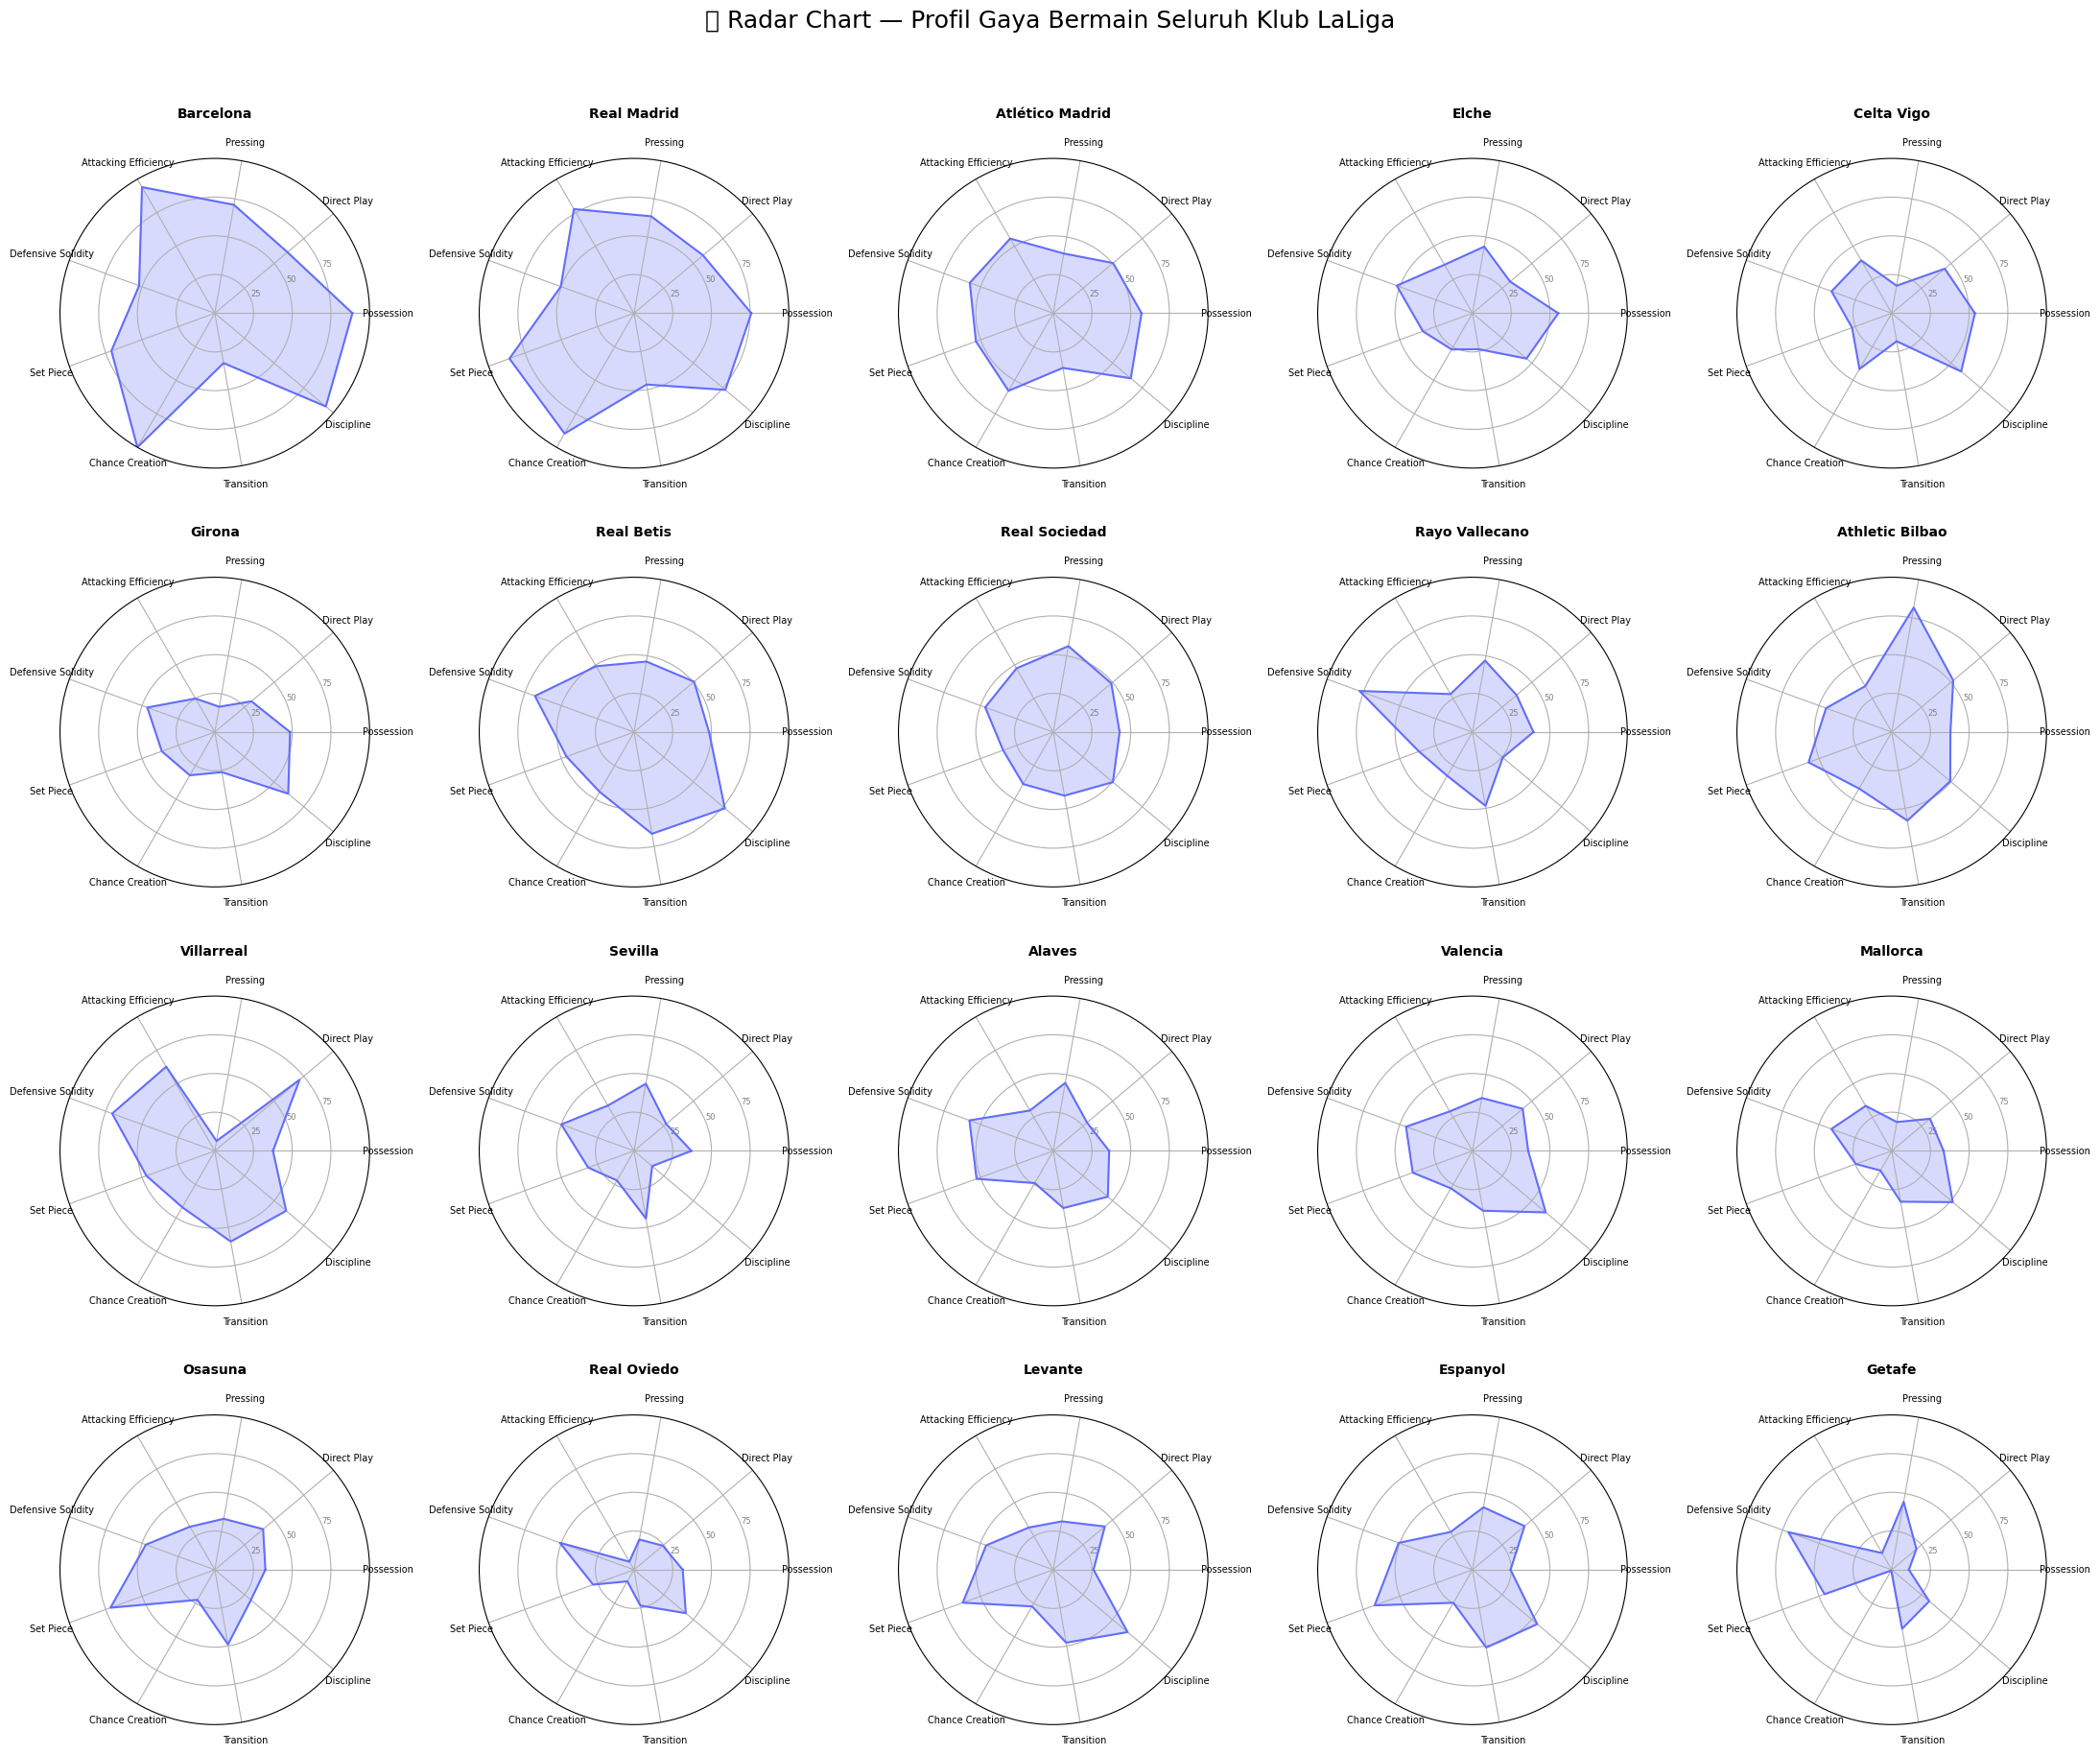

In [28]:
# --- Grid Radar Chart: Seluruh 20 Klub (Matplotlib) ---
clubs_sorted = df_scores.sort_values("Possession Score", ascending=False)["club"].tolist()
labels_short = [c.replace(" Score", "") for c in score_cols]
num_vars = len(score_cols)

# Sudut untuk setiap sumbu radar
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Tutup lingkaran

fig, axes = plt.subplots(4, 5, figsize=(22, 18), subplot_kw=dict(polar=True))
fig.suptitle("🕸️ Radar Chart — Profil Gaya Bermain Seluruh Klub LaLiga", fontsize=18, y=1.02)

for idx, (ax, club) in enumerate(zip(axes.flat, clubs_sorted)):
    row = df_scores[df_scores["club"] == club].iloc[0]
    values = [row[col] for col in score_cols]
    values += values[:1]  # Tutup lingkaran

    ax.fill(angles, values, alpha=0.25, color="#636EFA")
    ax.plot(angles, values, color="#636EFA", linewidth=1.5)
    ax.set_ylim(0, 100)
    ax.set_yticks([25, 50, 75])
    ax.set_yticklabels(["25", "50", "75"], fontsize=6, color="gray")
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels_short, fontsize=7)
    ax.set_title(club, fontsize=10, fontweight="bold", pad=15)

plt.tight_layout()
plt.show()

---

## 10. Output Dataset — `teams_ml_features`

Tahap terakhir: menyusun dataset akhir yang siap digunakan oleh **notebook clustering berikutnya**.

Dataset ini berisi:
- `club` — Nama klub (label/identifier, bukan fitur)
- 9 kolom **Style Score** (skala 0–100)

Dataset ini akan menjadi **input langsung** untuk algoritma clustering (KMeans, Hierarchical, DBSCAN, dll.).

In [ ]:
# ===========================================================================
# Buat DataFrame Final: teams_ml_features
# ===========================================================================

teams_ml_features = df_scores.copy()

# Urutkan berdasarkan nama klub (konsistensi)
teams_ml_features = teams_ml_features.sort_values("club").reset_index(drop=True)

print("📦 Dataset Final: teams_ml_features")
print("=" * 50)
print(f"   Shape : {teams_ml_features.shape}")
print(f"   Kolom : {list(teams_ml_features.columns)}")
print(f"   Tipe  : {teams_ml_features.dtypes.value_counts().to_dict()}")
print()
teams_ml_features

In [ ]:
# --- Statistik Deskriptif Dataset Final ---
teams_ml_features.describe().round(2)

In [ ]:
# --- Korelasi antar Style Scores ---
corr = teams_ml_features[score_cols].corr()

fig = px.imshow(
    corr,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1, zmax=1,
    title="📊 Correlation Matrix — Style Scores",
    aspect="auto",
)

fig.update_layout(width=750, height=650, font=dict(size=10))
fig.show()

### 💾 Simpan Dataset ke CSV

Dataset final disimpan ke file CSV agar bisa diakses oleh notebook clustering tanpa perlu mengulang seluruh proses feature engineering.

In [ ]:
# --- Simpan ke CSV ---
output_dir = PROJECT_ROOT / "data" / "ml_ready"
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "teams_ml_features.csv"
teams_ml_features.to_csv(output_path, index=False)

print(f"✅ Dataset disimpan ke: {output_path}")
print(f"   Size: {output_path.stat().st_size / 1024:.1f} KB")

---

## ✅ Kesimpulan

Notebook ini telah menyelesaikan 3 tahap utama:

### 1. Feature Selection
- Memilih **fitur-fitur relevan** dari 124+ kolom berdasarkan konsep taktis sepakbola.
- Fitur dikelompokkan menjadi **9 dimensi gaya bermain**.

### 2. Feature Engineering
- Menormalisasi semua fitur menggunakan **Min-Max Scaling** ke skala 0–100.
- Menangani fitur *inverted* (dimana nilai tinggi = performa buruk).

### 3. Style Scoring
- Menghitung **9 skor komposit** menggunakan simple average.
- Memvalidasi hasil melalui ranking dan visualisasi radar chart.

### Output
- File: `data/ml_ready/teams_ml_features.csv`
- Berisi: 20 baris (klub) × 10 kolom (club + 9 style scores)
- Siap digunakan pada **notebook clustering berikutnya**.

---

*Notebook berikutnya: Clustering Analysis — Mengelompokkan tim berdasarkan style scores untuk mengidentifikasi pola gaya bermain di LaLiga.*